# How to determine spectral overlap integrals

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Get emission data of donor and absorption data of acceptor

In [2]:
cy5_emission_path = os.path.join(
    src_path, r"src\fluorophore_collection\cy5_data\emission.csv"
)
cy5_emission_data = pd.read_csv(cy5_emission_path)

cy5_absorption_path = os.path.join(
    src_path, r"src\fluorophore_collection\cy5_data\absorption_s0.csv"
)
cy5_absorption_data = pd.read_csv(cy5_absorption_path)

### Interpolation of missing data points

array([[<Axes: title={'center': 'absorption'}, xlabel='wavelength [nm]', ylabel='$\\epsilon\\ [M^{-1}cm^{-1}]$'>]],
      dtype=object)

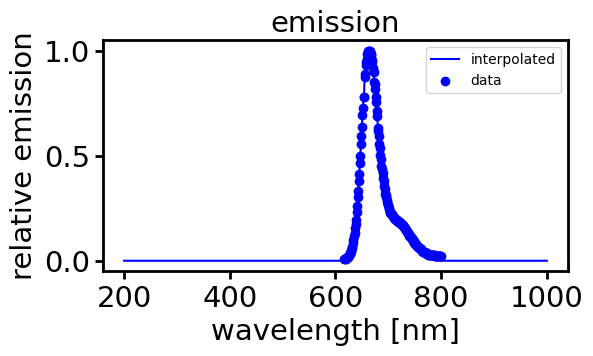

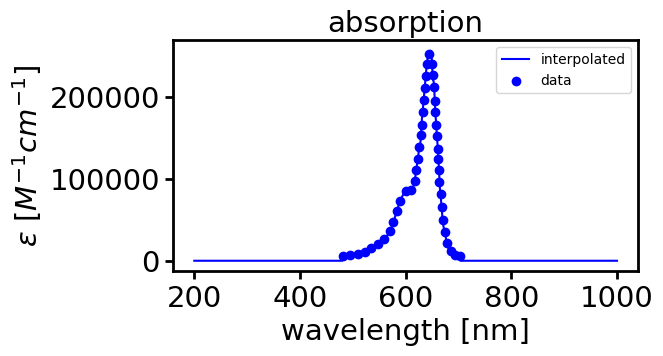

In [3]:
minimum_wavelength, maximum_wavelength = 200, 1000
wavelengths_of_interest = np.arange(
    minimum_wavelength, maximum_wavelength + 1, 1, dtype=float
)
interpolated_em = tr.interpolate_data(
    minimum_wavelength=minimum_wavelength,
    maximum_wavelength=maximum_wavelength,
    data=cy5_emission_data,
)
interpolated_abs = tr.interpolate_data(
    minimum_wavelength=minimum_wavelength,
    maximum_wavelength=maximum_wavelength,
    data=cy5_absorption_data,
)

axes = fi.universal_figure(
    type_="line", data=[wavelengths_of_interest, interpolated_em], label="interpolated"
)
fi.universal_figure(
    type_="scatter",
    data=[cy5_emission_data["Wavelength"], cy5_emission_data["y"]],
    axes=axes[0],
    label="data",
    legend=True,
    title="emission",
    ylabel="relative emission",
    xlabel="wavelength [nm]",
)
axes = fi.universal_figure(
    type_="line", data=[wavelengths_of_interest, interpolated_abs], label="interpolated"
)
fi.universal_figure(
    type_="scatter",
    data=[cy5_absorption_data["Wavelength"], cy5_absorption_data["y"]],
    axes=axes[0],
    label="data",
    legend=True,
    title="absorption",
    ylabel=r"$\epsilon\ [M^{-1}cm^{-1}]$",
    xlabel="wavelength [nm]",
)

### Calculation of spectral overlap integrals and FRET rate

In [4]:
J = fo.calculate_spectral_overlap_integral(
    donor=interpolated_em,
    acceptor=interpolated_abs,
    wavelengths=wavelengths_of_interest,
)
r_FRET = fo.calculate_fret_rate(
    distance=10,
    emission_rate=1e8,
    spectral_overlap_integral=J,
    dipole_orientation_factor=2 / 3,
    refractive_index=1,
)